# JPEG AI as a Threat to Deepfake Detection

Main notebook. Dataset: **ProGAN** (CNNDetection test set). Detector: **CNNDetection** (pre-trained ResNet50). Codec: **JPEG AI reference software**.

Structure (guidelines): Imports - Globals - Utils - Data - Network - Train - Evaluation.

# Imports

In [2]:
import os, sys, random, subprocess
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models import resnet50
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_fscore_support, roc_curve)

from google.colab import drive
drive.mount('/content/drive')
print('Imports OK | device:', 'cuda' if torch.cuda.is_available() else 'cpu')

Mounted at /content/drive
Imports OK | device: cuda


# Globals

Variables used throughout the notebook (paths, bitrates, seed).

In [3]:
device        = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED          = 42
BPP_LIST      = [0.12, 0.25, 0.50, 0.75]      # target bitrates (bits per pixel)
VALID_IMG_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

DATASET_PATH = '/content/drive/MyDrive/ProGAN_Dataset'         # originals + compressed (on Drive)
TRAIN_DATASET = '/content/drive/MyDrive/ProGAN_Train_Dataset'
PROGAN_ROOT  = '/content/progan_data/progan'                   # ProGAN source (after download)
JPEGAI_DIR   = '/content/jpeg-ai-reference-software'           # JPEG AI reference software
WEIGHTS_DIR  = '/content/drive/MyDrive/cnndetection_weights'   # detector weights cache (on Drive)


print('Globals OK | DATASET_PATH =', DATASET_PATH)

Globals OK | DATASET_PATH = /content/drive/MyDrive/ProGAN_Dataset


# Utils

Support functions (standard detection metrics).

In [4]:
def compute_metrics(labels, scores, thr=0.5):
    """Standard metrics for binary detection. scores = P(fake), label fake=1."""
    labels, scores = np.asarray(labels), np.asarray(scores)
    pred = (scores > thr).astype(int)
    real, fake = (labels == 0), (labels == 1)
    pr, rc, f1, _ = precision_recall_fscore_support(labels, pred, average='binary', zero_division=0)
    roc_fpr, roc_tpr, _ = roc_curve(labels, scores)
    eer = float(roc_fpr[np.nanargmin(np.abs(roc_fpr - (1 - roc_tpr)))])
    return dict(
        AUC=roc_auc_score(labels, scores),
        AP=average_precision_score(labels, scores),
        Acc=(pred == labels).mean(),
        BalAcc=0.5 * ((pred[fake] == 1).mean() + (pred[real] == 0).mean()),
        FPR=float((pred[real] == 1).mean()),   # pristine flagged as fake (false alarms)
        FNR=float((pred[fake] == 0).mean()),   # fakes classified as pristine (missed)
        Prec=pr, Rec=rc, F1=f1, EER=eer,
    )

print('Utils OK')

Utils OK


In [ ]:
import os, numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.fftpack import dct

SIZE = 256

def load_gray(path, size=SIZE):
    img = Image.open(path).convert('L')
    if img.size != (size, size):
        img = img.resize((size, size))
    return np.asarray(img, float)

def residual(g, sigma=1.0):
    return g - gaussian_filter(g, sigma)          # high-pass: isola il fingerprint fine

def avg_fft_residual(folder, n=150):
    acc, k = np.zeros((SIZE, SIZE)), 0
    for f in sorted(os.listdir(folder))[:n]:
        F = np.fft.fftshift(np.abs(np.fft.fft2(residual(load_gray(os.path.join(folder, f))))))
        acc += F; k += 1
    return np.log1p(acc / max(k, 1))              # spettro 2D medio (log)

def radial_psd(spec2d):
    h, w = spec2d.shape
    y, x = np.indices((h, w))
    r = np.hypot(x - w // 2, y - h // 2).astype(int)
    return np.bincount(r.ravel(), spec2d.ravel()) / np.maximum(np.bincount(r.ravel()), 1)

print('Forensic helpers OK')

Forensic helpers OK


# Data

Data management: ProGAN download, JPEG AI setup, real/fake split construction and compression at multiple bitrates (reproducible pipeline, Objective 1).

**The cells in this section are only needed to (re)generate the compressed dataset.** If it is already on Drive (`DATASET_PATH`), evaluation only needs Imports/Globals/Network/Evaluation.

In [ ]:
# (Data) Download the CNNDetection ProGAN test set from Google Drive
FILE_ID = '1NZufxaZrjapdsJE_jjP0LGfh1piBy_9i'   # progan_testset.zip file

if not os.path.isdir(PROGAN_ROOT):
    !rm -rf /content/progan_data /content/progan_testset.zip
    !{sys.executable} -m gdown {FILE_ID} -O /content/progan_testset.zip
    !mkdir -p /content/progan_data
    !unzip -q /content/progan_testset.zip -d /content/progan_data
!ls /content/progan_data/progan | head

Downloading...
From (original): https://drive.google.com/uc?id=1NZufxaZrjapdsJE_jjP0LGfh1piBy_9i
From (redirected): https://drive.google.com/uc?id=1NZufxaZrjapdsJE_jjP0LGfh1piBy_9i&confirm=t&uuid=adff1f79-4e7b-441a-9971-6ed3067a82f9
To: /content/progan_testset.zip
100% 834M/834M [00:08<00:00, 93.0MB/s]
airplane
bicycle
bird
boat
bottle
bus
car
cat
chair
cow


In [ ]:
import os, random
from PIL import Image

EVAL_N = 200    # quante ne ha prese il test set (ProGAN_Dataset)

def gather(marker):
    out = []
    for dp, _, fs in os.walk(PROGAN_ROOT):
        for f in fs:
            p = os.path.join(dp, f)
            if f.lower().endswith(('.png', '.jpg', '.jpeg')) and marker in p:
                out.append(p)
    return sorted(out)

def build_disjoint_train(count=100, seed=42):
    real, fake = gather('/0_real/'), gather('/1_fake/')
    rng = random.Random(seed); rng.shuffle(real); rng.shuffle(fake)   # STESSO shuffle del test
    for cls, lst in [('real', real), ('fake', fake)]:
        print(f'{cls}: disponibili {len(lst)}')
        sel = lst[EVAL_N: EVAL_N + count]                              # range DISGIUNTO dalle prime 200
        od = os.path.join(TRAIN_DATASET, f'{cls}_original'); os.makedirs(od, exist_ok=True)
        for i, p in enumerate(sel):
            Image.open(p).convert('RGB').save(os.path.join(od, f'{cls}_{i:05d}.png'))
        print(f'  train {cls}: {len(sel)}  (indici {EVAL_N}..{EVAL_N+len(sel)})')

build_disjoint_train(count=400)

real: disponibili 4000
  train real: 400  (indici 200..600)
fake: disponibili 4000
  train fake: 400  (indici 200..600)


In [ ]:
# (Data) JPEG AI reference software setup (ONLY for compression; ~20-40 min)
if not os.path.exists('/content/miniconda/bin/conda'):
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/miniconda.sh
    !bash /content/miniconda.sh -b -p /content/miniconda
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']
os.environ.pop('PYTHONPATH', None)
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!apt-get -qq install -y git-lfs doxygen graphviz
!git lfs install
%cd /content
if not os.path.isdir(JPEGAI_DIR):
    !git clone https://gitlab.com/wg1/jpeg-ai/jpeg-ai-reference-software.git
%cd /content/jpeg-ai-reference-software
!git lfs fetch
!git lfs checkout
!make setup_env
!conda env list | grep jpeg_ai_vm || echo 'jpeg_ai_vm env NOT created'
print('JPEG AI setup done.')

PREFIX=/content/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /content/miniconda
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Selecting previously unselected package libllvm14:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../0-libllvm14_1%3a14.0.0-1ubuntu1.1_amd64.deb ...
Unpacking libllvm14:amd64 (1:14.0.0-1ubuntu1.1) ...
Selecting previously unselected package libclang-cpp14.
Preparing 

In [ ]:
# (Data) Functions: real/fake split construction + JPEG AI compression (encoder with -r)
def build_split_by_marker(root, dataset_path, n_per_class=None, seed=SEED,
                          real_marker='/0_real/', fake_marker='/1_fake/'):
    def gather(marker):
        out = []
        for dp, _, fs in os.walk(root):
            for f in fs:
                if f.lower().endswith(VALID_IMG_EXT):
                    p = os.path.join(dp, f)
                    if marker in p:
                        out.append(p)
        return sorted(out)
    real, fake = gather(real_marker), gather(fake_marker)
    rng = random.Random(seed); rng.shuffle(real); rng.shuffle(fake)
    if n_per_class is not None:
        real, fake = real[:n_per_class], fake[:n_per_class]
    for cls, lst in [('real', real), ('fake', fake)]:
        od = os.path.join(dataset_path, f'{cls}_original'); os.makedirs(od, exist_ok=True)
        n = 0
        for p in lst:
            try:
                Image.open(p).convert('RGB').save(os.path.join(od, f'{cls}_{n:05d}.png')); n += 1
            except Exception as e:
                print('skip', p, e)
        print(f'{cls}_original: {n} (out of {len(lst)})')

def _jpegai_run(cmd, jpegai_dir, env='jpeg_ai_vm'):
    r = subprocess.run(['conda', 'run', '-n', env] + cmd, cwd=jpegai_dir, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError('JPEG AI failed: ' + r.stderr[-1500:])

def compress_image_jpegai(src, out_png, bpp, jpegai_dir, profile='base', stream_dir='/content/jpegai_streams'):
    os.makedirs(stream_dir, exist_ok=True)
    cfg = ['cfg/tools_off.json', f'cfg/profiles/{profile}.json']
    stream = os.path.join(stream_dir, os.path.splitext(os.path.basename(src))[0] + f'_{bpp}.bin')
    try:
        _jpegai_run(['python', '-m', 'src.reco.coders.encoder', src, stream, '-r', out_png,
                     '--set_target_bpp', str(int(round(bpp * 100))), '--cfg'] + cfg, jpegai_dir)
    finally:
        if os.path.exists(stream): os.remove(stream)

def compress_dataset_jpegai(dataset_path, bpp_list, jpegai_dir):
    for cls in ('real', 'fake'):
        sd = os.path.join(dataset_path, f'{cls}_original')
        imgs = [f for f in sorted(os.listdir(sd)) if f.lower().endswith(VALID_IMG_EXT)]
        print('===', cls, len(imgs), 'images ===')
        for bpp in bpp_list:
            od = os.path.join(dataset_path, f'{cls}_bpp{bpp}'); os.makedirs(od, exist_ok=True)
            for fn in imgs:
                out = os.path.join(od, os.path.splitext(fn)[0] + '.png')
                if os.path.exists(out):
                    continue
                try:
                    compress_image_jpegai(os.path.join(sd, fn), out, bpp, jpegai_dir)
                except Exception as e:
                    print('   ', fn, e)
    print('Compression done.')

print('Data functions OK')

Data functions OK


In [ ]:
# (Data) Generate the compressed ProGAN dataset (AFTER download + JPEG AI setup)
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']
build_split_by_marker(PROGAN_ROOT, DATASET_PATH, n_per_class=200)
compress_dataset_jpegai(DATASET_PATH, BPP_LIST, JPEGAI_DIR)

In [ ]:
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']
compress_dataset_jpegai(TRAIN_DATASET, BPP_LIST, JPEGAI_DIR)   # ~400/classe x 4 bpp, immagini 256 -> veloce

=== real 100 images ===


In [4]:
import os, random
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

train_tf = transforms.Compose([
    transforms.CenterCrop(224),                 # stesso preprocessing dell'eval (niente resize)
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PairedBPPDataset(Dataset):
    def __init__(self, root_dir, bpp_pair, prob_compressed=0.5, transform=None):
        self.root_dir, self.bpp_pair = root_dir, bpp_pair
        self.prob_compressed, self.transform = prob_compressed, transform
        self.samples = []
        for cls, lab in [('real', 0), ('fake', 1)]:
            for fn in os.listdir(os.path.join(root_dir, f'{cls}_original')):
                self.samples.append((fn, cls, lab))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fn, cls, label = self.samples[idx]
        if random.random() < self.prob_compressed:
            b = random.choice(self.bpp_pair)
            path = os.path.join(self.root_dir, f'{cls}_bpp{b}', fn)
        else:
            path = os.path.join(self.root_dir, f'{cls}_original', fn)
        return self.transform(Image.open(path).convert('RGB')), label

BATCH_SIZE = 16
ds_low  = PairedBPPDataset(TRAIN_DATASET, [0.12, 0.25], 0.5, train_tf)
ds_high = PairedBPPDataset(TRAIN_DATASET, [0.50, 0.75], 0.5, train_tf)
train_loader_low  = DataLoader(ds_low,  batch_size=BATCH_SIZE, shuffle=True)
train_loader_high = DataLoader(ds_high, batch_size=BATCH_SIZE, shuffle=True)
print('low:', len(ds_low), '| high:', len(ds_high))

low: 200 | high: 200


In [13]:
from PIL import ImageFilter

SHARP_PERCENT = 0   # forza dello sharpening (100≈nullo; prova 150 / 200 / 300)

def sharpen(img):
    return img.filter(ImageFilter.UnsharpMask(radius=2, percent=SHARP_PERCENT, threshold=3))

@torch.no_grad()
def cnndet_predict_sharp(path):
    img = sharpen(Image.open(path).convert('RGB'))   # <-- unico passo aggiunto
    x = cnn_tf(img).unsqueeze(0).to(device)          # stesso preprocessing (CenterCrop 224 + norm)
    return float(torch.sigmoid(cnn(x).squeeze()))

print('sharpen predict ready | percent =', SHARP_PERCENT)

sharpen predict ready | percent = 0


# Network

Pre-trained **CNNDetection** detector (Wang et al. 2020): ResNet50 with a single output (logit -> sigmoid = P(fake)). Two variants: `prob0.1` (little data augmentation, more vulnerable to compression) and `prob0.5` (robust). Weights are cached on Drive.

In [5]:
# (Network) Download CNNDetection weights (cached on Drive, only the first time)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
urls = {
    'blur_jpg_prob0.1.pth': 'https://www.dropbox.com/s/h7tkpcgiwuftb6g/blur_jpg_prob0.1.pth?dl=1',
    'blur_jpg_prob0.5.pth': 'https://www.dropbox.com/s/2g2jagq2jn1fd0i/blur_jpg_prob0.5.pth?dl=1',
}
for name, url in urls.items():
    dst = os.path.join(WEIGHTS_DIR, name)
    if not os.path.exists(dst):
        !wget -q '{url}' -O '{dst}'
!ls -la {WEIGHTS_DIR}

total 551646
-rw------- 1 root root 282442597 Jul  1 10:26 blur_jpg_prob0.1.pth
-rw------- 1 root root 282442597 Jul  1 10:27 blur_jpg_prob0.5.pth


In [7]:
# (Network) Load a detector variant + prediction function
DETECTOR_VARIANT = 'blur_jpg_prob0.5.pth'   # use 'blur_jpg_prob0.5.pth' for the robust detector

cnn = resnet50(num_classes=1)
sd = torch.load(os.path.join(WEIGHTS_DIR, DETECTOR_VARIANT), map_location=device)
sd = sd.get('model', sd)
sd = {(k[7:] if k.startswith('module.') else k): v for k, v in sd.items()}
print(cnn.load_state_dict(sd))
cnn = cnn.to(device).eval()

# CNNDetection preprocessing: no resize (preserves the fingerprint), center crop 224, ImageNet normalize
cnn_tf = T.Compose([
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def cnndet_predict(path):
    x = cnn_tf(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
    return float(torch.sigmoid(cnn(x).squeeze()))   # P(fake)

print('Detector ready:', DETECTOR_VARIANT)

<All keys matched successfully>
Detector ready: blur_jpg_prob0.5.pth


In [18]:
from torchvision.models import resnet50

def load_base(variant):
    m = resnet50(num_classes=1)
    sd = torch.load(os.path.join(WEIGHTS_DIR, variant), map_location=device)
    sd = sd.get('model', sd)
    sd = {(k[7:] if k.startswith('module.') else k): v for k, v in sd.items()}
    m.load_state_dict(sd)
    return m.to(device)

BASE = 'blur_jpg_prob0.1.pth'          # poi RIPETI tutto con 'blur_jpg_prob0.5.pth'
model_low, model_high = load_base(BASE), load_base(BASE)
print('base loaded:', BASE)

base loaded: blur_jpg_prob0.1.pth


# Train

The project uses **pre-trained detectors** for the baseline evaluation: there is **no training** in this phase. This section is reserved for the optional fine-tuning for the **mitigation strategies** (objective 3).

In [19]:
import torch.optim as optim
from tqdm import tqdm

EPOCHS, LR = 8, 5e-5
criterion = torch.nn.BCEWithLogitsLoss()
optimizer_low  = optim.Adam(model_low.parameters(),  lr=LR)
optimizer_high = optim.Adam(model_high.parameters(), lr=LR)

def train_expert(model, loader, optimizer, name):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(loader, desc=name, leave=False)
    for images, labels in loop:
        images = images.to(device); labels = labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        preds = (outputs > 0.0).float()
        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=f'{loss.item():.4f}')
    print(f'  {name:11s} -> loss {running_loss/total:.4f} | acc {correct/total:.4f}')

for epoch in range(EPOCHS):
    print(f'--- Epoch {epoch+1}/{EPOCHS} ---')
    train_expert(model_low,  train_loader_low,  optimizer_low,  'Low expert')
    train_expert(model_high, train_loader_high, optimizer_high, 'High expert')

tag = BASE.replace('blur_jpg_', '').replace('.pth', '')
torch.save(model_low.state_dict(),  f'/content/drive/MyDrive/expert_low_{tag}.pth')
torch.save(model_high.state_dict(), f'/content/drive/MyDrive/expert_high_{tag}.pth')
print('experts saved for', tag)

--- Epoch 1/8 ---


  Low expert  -> loss 1.5151 | acc 0.8050


  High expert -> loss 0.4113 | acc 0.9400
--- Epoch 2/8 ---


  Low expert  -> loss 0.8272 | acc 0.8850


  High expert -> loss 0.0487 | acc 0.9900
--- Epoch 3/8 ---


...

  High expert -> loss 0.1934 | acc 0.9600
--- Epoch 7/8 ---


  Low expert  -> loss 0.5634 | acc 0.8800


  High expert -> loss 0.1170 | acc 0.9750
--- Epoch 8/8 ---


  Low expert  -> loss 0.4107 | acc 0.8850


  High expert -> loss 0.0555 | acc 0.9850
experts saved for prob0.1


# Evaluation

Detector evaluation on `original` and at each JPEG AI compression level. Standard metrics (AUC, AP, Accuracy, Balanced Acc, F1, EER) as a function of bitrate = **degradation curve** (Objective 1).

In [24]:
# (Evaluation) Per-condition scores + detailed report for the original
def scores_for_condition(suffix):
    s, y = [], []
    for cls, lab in [('real', 0), ('fake', 1)]:
        d = os.path.join(DATASET_PATH, f'{cls}_{suffix}')
        if not os.path.isdir(d):
            continue
        for f in sorted(os.listdir(d)):
            s.append(cnndet_predict(os.path.join(d, f))); y.append(lab)
    return np.array(y), np.array(s)

y, s = scores_for_condition('original')
print(f'ProGAN - ORIGINAL  (n={len(y)})')
for k, v in compute_metrics(y, s).items():
    print(f'  {k:7s} {v:.3f}')

ProGAN - ORIGINAL  (n=300)
  AUC     1.000
  AP      1.000
  Acc     0.997
  BalAcc  0.997
  FPR     0.000
  FNR     0.007
  Prec    1.000
  Rec     0.993
  F1      0.997
  EER     0.007


In [25]:
cols = ['AUC', 'AP', 'Acc', 'BalAcc', 'FPR', 'FNR', 'F1', 'EER']
print('CONDITION'.ljust(12) + ' ' + ' '.join(c.rjust(7) for c in cols) + '    n')
results = {}
for suf in ['original'] + [f'bpp{b}' for b in BPP_LIST]:
    y, s = scores_for_condition(suf)
    if len(y) == 0:
        print(suf.ljust(12) + '  (missing)'); continue
    m = compute_metrics(y, s); results[suf] = m
    print(suf.ljust(12) + ' ' + ' '.join(f'{m[c]:7.3f}' for c in cols) + f'    {len(y)}')

CONDITION        AUC      AP     Acc  BalAcc     FPR     FNR      F1     EER    n
original       1.000   1.000   0.997   0.997   0.000   0.007   0.997   0.007    300
bpp0.12        0.811   0.823   0.737   0.737   0.300   0.227   0.746   0.267    300
bpp0.25        0.937   0.939   0.853   0.853   0.180   0.113   0.858   0.140    300
bpp0.5         0.988   0.989   0.970   0.970   0.020   0.040   0.970   0.040    300
bpp0.75        0.997   0.997   0.973   0.973   0.007   0.047   0.973   0.013    300


In [14]:
@torch.no_grad()
def scores_with(predict_fn, suffix):
    y, s = [], []
    for cls, lab in [('real', 0), ('fake', 1)]:
        d = os.path.join(DATASET_PATH, f'{cls}_{suffix}')
        for fn in sorted(os.listdir(d)):
            s.append(predict_fn(os.path.join(d, fn))); y.append(lab)
    return np.array(y), np.array(s)

print(f'{"cond":9s} {"AUC base":>9} {"AUC sharp":>10} {"Acc base":>9} {"Acc sharp":>10}')
for suf in ['original'] + [f'bpp{b}' for b in BPP_LIST]:
    yb, sb = scores_with(cnndet_predict,       suf)   # base (nessun preprocessing)
    ys, ss = scores_with(cnndet_predict_sharp, suf)   # base + sharpening
    mb, ms = compute_metrics(yb, sb), compute_metrics(ys, ss)
    print(f'{suf:9s} {mb["AUC"]:9.3f} {ms["AUC"]:10.3f} {mb["Acc"]:9.3f} {ms["Acc"]:10.3f}')

cond       AUC base  AUC sharp  Acc base  Acc sharp
original      1.000      1.000     1.000      1.000
bpp0.12       0.781      0.781     0.683      0.683
bpp0.25       0.944      0.944     0.860      0.860
bpp0.5        0.996      0.996     0.960      0.960
bpp0.75       0.999      0.999     0.977      0.977


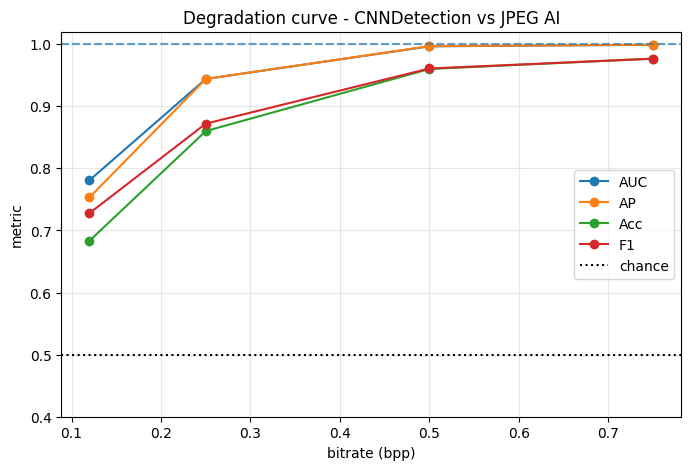

In [ ]:
# (Evaluation) Degradation curve plot
plt.figure(figsize=(8, 5))
for mname in ['AUC', 'AP', 'Acc', 'F1']:
    plt.plot(BPP_LIST, [results[f'bpp{b}'][mname] for b in BPP_LIST], 'o-', label=mname)
    plt.axhline(results['original'][mname], ls='--', alpha=0.25)
plt.axhline(0.5, color='k', ls=':', label='chance')
plt.xlabel('bitrate (bpp)'); plt.ylabel('metric'); plt.ylim(0.4, 1.02)
plt.title('Degradation curve - CNNDetection vs JPEG AI')
plt.legend(); plt.grid(alpha=0.3); plt.show()

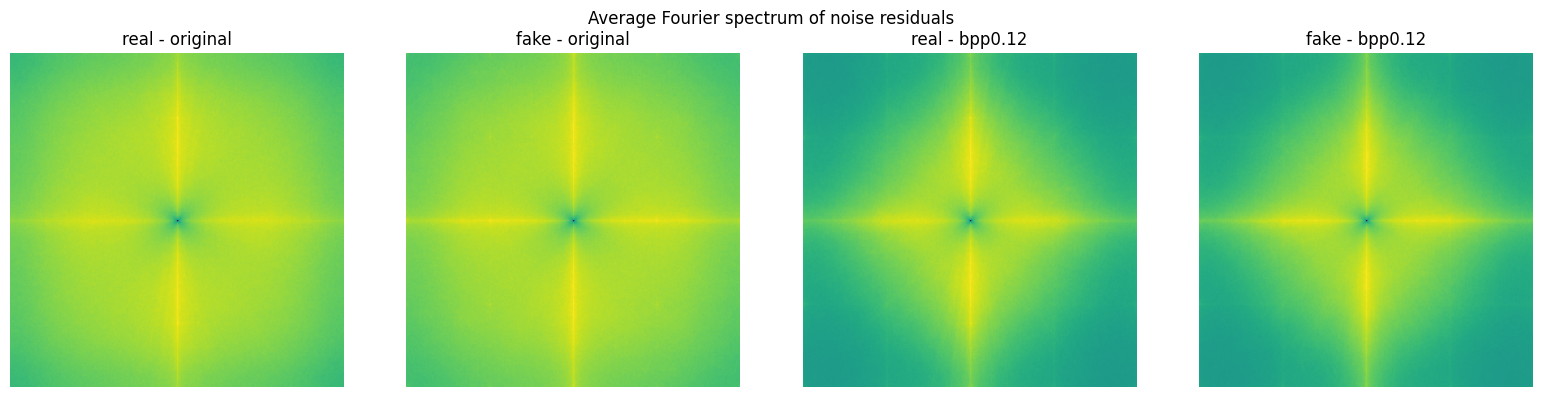

In [ ]:
BPP = 0.12   # livello compresso da confrontare (max effetto)
conds = [('real', 'original'), ('fake', 'original'), ('real', f'bpp{BPP}'), ('fake', f'bpp{BPP}')]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (cls, suf) in zip(axes, conds):
    S = avg_fft_residual(os.path.join(DATASET_PATH, f'{cls}_{suf}'))
    ax.imshow(S, cmap='viridis'); ax.set_title(f'{cls} - {suf}'); ax.axis('off')
plt.suptitle('Average Fourier spectrum of noise residuals'); plt.tight_layout(); plt.show()

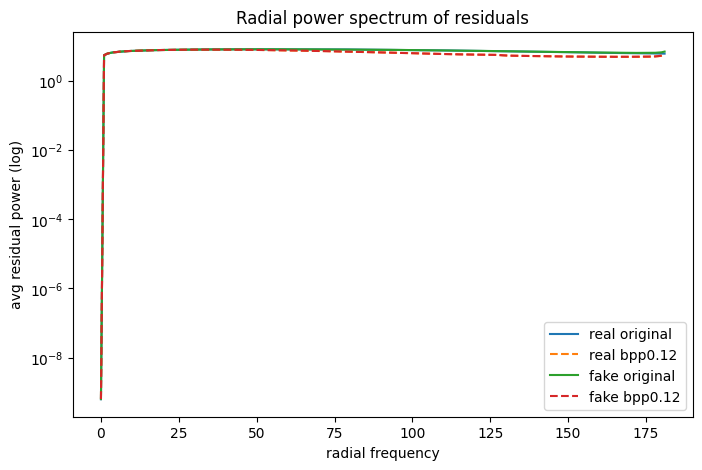

In [ ]:
BPP = 0.12
spec = {}
for cls in ['real', 'fake']:
    for suf in ['original', f'bpp{BPP}']:
        spec[(cls, suf)] = radial_psd(avg_fft_residual(os.path.join(DATASET_PATH, f'{cls}_{suf}')))

plt.figure(figsize=(8, 5))
for (cls, suf), p in spec.items():
    ls = '-' if suf == 'original' else '--'
    plt.semilogy(p, ls, label=f'{cls} {suf}')
plt.xlabel('radial frequency'); plt.ylabel('avg residual power (log)')
plt.title('Radial power spectrum of residuals'); plt.legend(); plt.show()

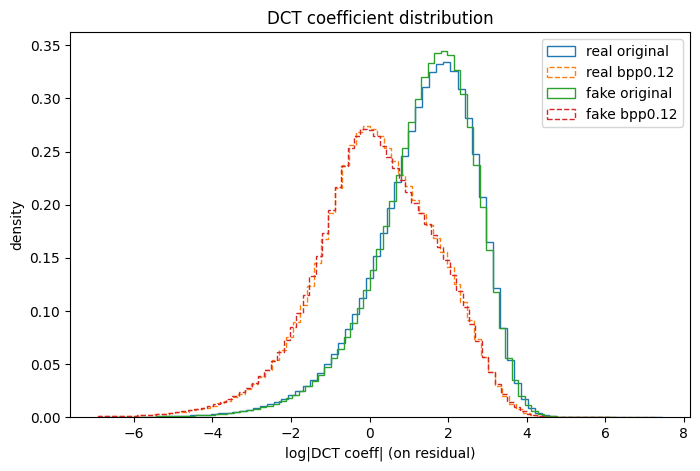

In [ ]:
def dct_logmag_samples(folder, n=150):
    vals = []
    for f in sorted(os.listdir(folder))[:n]:
        g = residual(load_gray(os.path.join(folder, f)))
        D = dct(dct(g, axis=0, norm='ortho'), axis=1, norm='ortho')
        vals.append(np.log(np.abs(D) + 1e-3).ravel())
    return np.concatenate(vals)

BPP = 0.12
plt.figure(figsize=(8, 5))
for cls in ['real', 'fake']:
    for suf, ls in [('original', '-'), (f'bpp{BPP}', '--')]:
        v = dct_logmag_samples(os.path.join(DATASET_PATH, f'{cls}_{suf}'))
        plt.hist(v, bins=80, density=True, histtype='step', linestyle=ls, label=f'{cls} {suf}')
plt.xlabel('log|DCT coeff| (on residual)'); plt.ylabel('density')
plt.title('DCT coefficient distribution'); plt.legend(); plt.show()

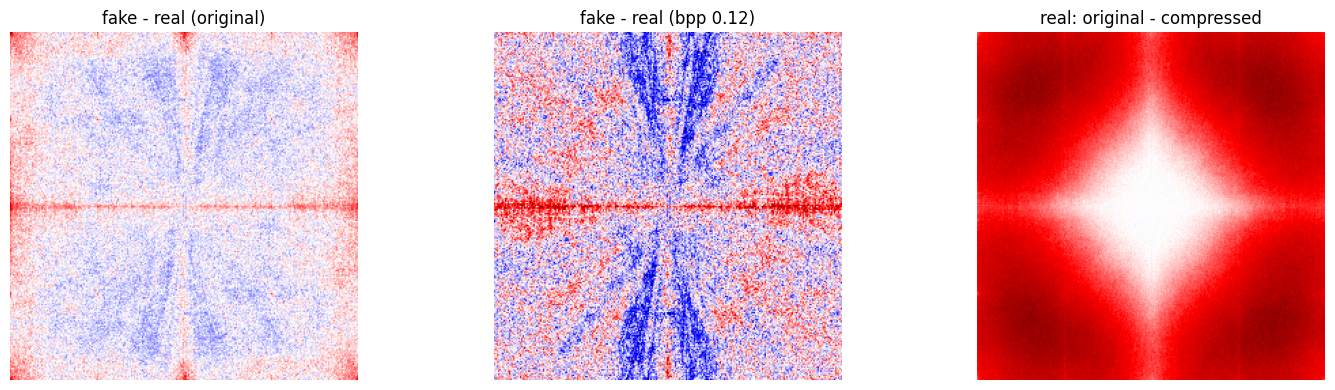

In [ ]:
def spec2d(cls, suf):
    return avg_fft_residual(os.path.join(DATASET_PATH, f'{cls}_{suf}'))

BPP = 0.12
so_r, so_f = spec2d('real', 'original'), spec2d('fake', 'original')
sc_r, sc_f = spec2d('real', f'bpp{BPP}'), spec2d('fake', f'bpp{BPP}')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
panels = [('fake - real (original)', so_f - so_r),
          (f'fake - real (bpp {BPP})', sc_f - sc_r),
          ('real: original - compressed', so_r - sc_r)]
for a, (t, D) in zip(ax, panels):
    m = np.abs(D).max()
    a.imshow(D, cmap='seismic', vmin=-m, vmax=m); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()